# Speech Emotion Recognition Using MiniLearn and Machine Learning Models

**CSE432 Final Compiled Notebook**

**By: Tyler Daley**

This notebook is the compiled final. It combines the weekly SER notebooks into one notebook.

The final metric tables are calculated directly in this notebook from the `week5_audio.csv` using the existing project data and MiniLearn code. Dataset and EDA tables/plots are recalculated directly from `week4_metadata.csv` and `week5_audio.csv`.


In [28]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
sys.dont_write_bytecode = True

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from minilearn.preprocessing.scaler import StandardScaler
from minilearn.preprocessing.split import train_test_split
from minilearn.metrics.metric import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from minilearn.classifiers.logistical_regression import LogisticRegression
from minilearn.classifiers.gaussian import GaussianNaiveBayes
from minilearn.classifiers.knn import KNN
from minilearn.classifiers.svm_linear import LinearSVM
from minilearn.classifiers.dtree import DecisionTreeClassifier
from minilearn.model.cross_valid import k_fold_split as kfold_split
from minilearn.model.cluster import KMeans
from minilearn.model.pca import PCA
from minilearn.model.ann import ANNClassifier as SimpleANNClassifier

from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.naive_bayes import GaussianNB as SKGaussianNB
from sklearn.neighbors import KNeighborsClassifier as SKKNN
from sklearn.svm import SVC as SKSVC
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans as SKKMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 123

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

def weighted_result(model, library, parameters, y_true, y_pred):
    return {
        "model": model,
        "library": library,
        "parameters": parameters,
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "weighted_precision": round(float(precision_score(y_true, y_pred, avg="weighted")), 4),
        "weighted_recall": round(float(recall_score(y_true, y_pred, avg="weighted")), 4),
        "weighted_F1": round(float(f1_score(y_true, y_pred, avg="weighted")), 4),
    }

def fit_and_score(model, model_name, library, parameters, X_train, y_train, X_test, y_test):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
    return weighted_result(model_name, library, parameters, y_test, y_pred)

def scale_train_test(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

def prepare_model_data():
    global X_all, y_all, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, X_all_scaled
    X_all = features[feature_cols].to_numpy(dtype=float)
    y_all = features["emotion"].to_numpy()
    np.random.seed(RANDOM_STATE)
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all)
    X_train_scaled, X_test_scaled = scale_train_test(X_train, X_test)
    X_all_scaled = StandardScaler().fit_transform(X_all)


## 1. Introduction

Speech Emotion Recognition (SER) is the task of predicting an emotion from speech audio. In this project, the target label is `emotion`, and the input features come from RAVDESS audio files.

RAVDESS is useful for this project because its filenames contain structured labels such as vocal channel, emotion, intensity, actor, and repetition. The project also builds **MiniLearn**, a small scikit-learn-style machine learning library, and compares MiniLearn models with scikit-learn versions.

The final pipeline is:

1. Parse RAVDESS filenames into metadata.
2. Extract audio features into a fixed-length feature table.
3. Remove metadata columns from `X` and use `emotion` as `y`.
4. Standardize audio features without test-set leakage.
5. Train MiniLearn and scikit-learn models.
6. Evaluate supervised models, clustering, PCA, and ANN results.


## 2. Data Acquisition, Cleaning, and Exploration

This section is based on the Week 4 notebook. This uses the generated `week4_metadata.csv` file. The metadata CSV was created by parsing the RAVDESS filenames.


In [29]:
metadata = pd.read_csv(DATA_DIR / "week4_metadata.csv")
features = pd.read_csv(DATA_DIR / "week5_audio.csv")

summary_meta_cols = ["path", "filename", "emotion", "intensity", "actor", "gender", "vocal_channel"]
summary_feature_cols = [c for c in features.columns if c not in summary_meta_cols]
summary = pd.DataFrame({
    "item": [
        "metadata_rows",
        "metadata_columns",
        "feature_rows",
        "feature_columns_total",
        "numeric_audio_feature_columns",
        "missing_values_metadata",
        "missing_values_features",
        "speech_files",
        "song_files",
    ],
    "value": [
        metadata.shape[0],
        metadata.shape[1],
        features.shape[0],
        features.shape[1],
        len(summary_feature_cols),
        int(metadata.isna().sum().sum()),
        int(features.isna().sum().sum()),
        int((metadata["vocal_channel"] == "speech").sum()),
        int((metadata["vocal_channel"] == "song").sum()),
    ],
})
summary


,item,value
0,metadata_rows,2452
1,metadata_columns,17
2,feature_rows,2452
3,feature_columns_total,731
4,numeric_audio_feature_columns,724
5,missing_values_metadata,0
6,missing_values_features,0
7,speech_files,1440
8,song_files,1012


The dataset summary shows that the etadata and feature files both contain 2,452 rows. The feature table contains 731 total columns, including 724 numeric audio feature columns after removing metadata. There were no missing values in either.


In [30]:
metadata.head()


,path,filename,modality_code,vocal_channel_code,emotion_code,intensity_code,statement_code,repetition_code,actor_code,modality,vocal_channel,emotion,intensity,statement,repetition,actor,gender
0,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,audio-only,speech,neutral,normal,Kids are talking by the door,1st,1,male
1,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,audio-only,speech,neutral,normal,Kids are talking by the door,2nd,1,male
2,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,audio-only,speech,neutral,normal,Dogs are sitting by the door,1st,1,male
3,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,audio-only,speech,neutral,normal,Dogs are sitting by the door,2nd,1,male
4,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,audio-only,speech,calm,normal,Kids are talking by the door,1st,1,male


The metadata table stores the parsed filename fields. The important target column is `emotion`. Other useful fields include `vocal_channel`, `intensity`, `actor`, and `gender`.


In [31]:
filename_parts = pd.DataFrame({
    "Position": [1, 2, 3, 4, 5, 6, 7],
    "Meaning": ["Modality", "Vocal channel", "Emotion", "Intensity", "Statement", "Repetition", "Actor"],
    "Example / Notes": ["03 = audio-only", "01 = speech, 02 = song", "classification target", "normal or strong", "sentence code", "first or second repetition", "actor ID; used to infer gender"],
})
filename_parts


,Position,Meaning,Example / Notes
0,1,Modality,03 = audio-only
1,2,Vocal channel,"01 = speech, 02 = song"
2,3,Emotion,classification target
3,4,Intensity,normal or strong
4,5,Statement,sentence code
5,6,Repetition,first or second repetition
6,7,Actor,actor ID; used to infer gender


This table summarizes how the RAVDESS filename was parsed in the Week 4. The third position is the most important for this project because it gives the `emotion` label.


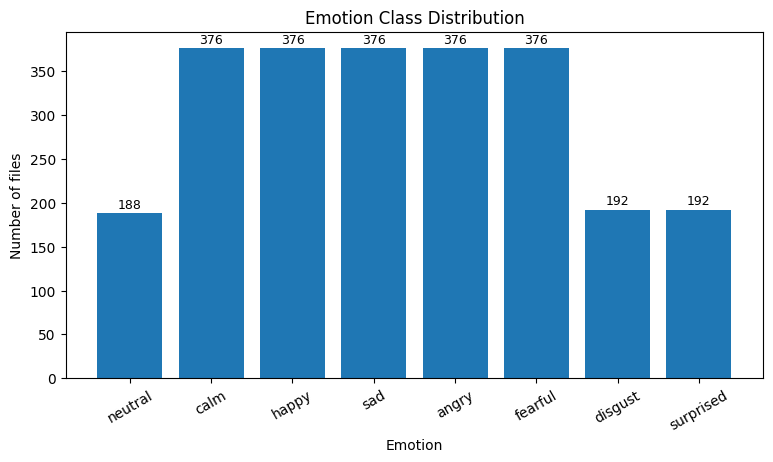

In [32]:
emotion_order = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
emotion_counts = metadata["emotion"].value_counts().reindex(emotion_order)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(emotion_counts.index, emotion_counts.values)
ax.set_title("Emotion Class Distribution")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of files")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(emotion_counts.values):
    ax.text(i, v + 6, str(v), ha="center", fontsize=9)
plt.show()


The emotion distribution is not perfectly balanced. Angry, calm, fearful, happy, and sad each have 376 files, while neutral has 188 and disgust/surprised each have 192. This matters because lower-support classes can be harder to learn and evaluate.


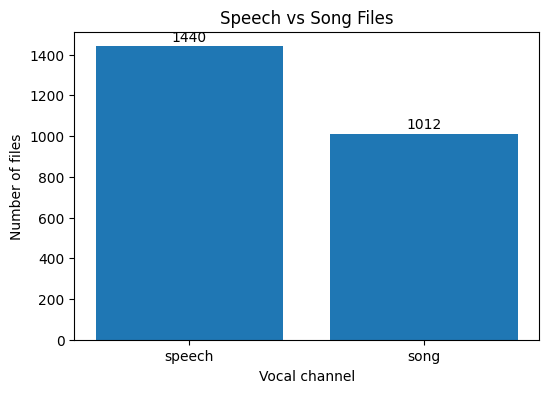

In [33]:
vocal_counts = metadata["vocal_channel"].value_counts().reindex(["speech", "song"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(vocal_counts.index, vocal_counts.values)
ax.set_title("Speech vs Song Files")
ax.set_xlabel("Vocal channel")
ax.set_ylabel("Number of files")
for i, v in enumerate(vocal_counts.values):
    ax.text(i, v + 25, str(v), ha="center", fontsize=10)
plt.show()


There are more speech files than song files. The project still keeps both vocal channels in the generated feature table, but the model target remains emotion.


In [34]:
pd.crosstab(metadata["emotion"], metadata["vocal_channel"]).reindex(emotion_order)


vocal_channel,song,speech
emotion,,
neutral,92,96
calm,184,192
happy,184,192
sad,184,192
angry,184,192
fearful,184,192
disgust,0,192
surprised,0,192


The emotion by vocal-channel table shows that disgust and surprised appear only in speech. This also helps explain why the emotion class counts are uneven.


## 3. Feature Engineering

This section is based on the Week 5 notebook. The audio feature CSV already exists as `week5_audio.csv`, so this just inspects the generated feature table and uses it for the final model summaries.


In [35]:
meta_cols = ["path", "filename", "emotion", "intensity", "actor", "gender", "vocal_channel"]
feature_cols = [c for c in features.columns if c not in meta_cols]

pd.DataFrame({
    "Item": ["Rows", "Total columns", "Metadata columns removed from X", "Numeric audio feature columns"],
    "Value": [features.shape[0], features.shape[1], len(meta_cols), len(feature_cols)],
})


,Item,Value
0,Rows,2452
1,Total columns,731
2,Metadata columns removed from X,7
3,Numeric audio feature columns,724


The feature table has one row per audio file. The seven metadata columns are removed from the model input matrix `X`, and `emotion` is used as the target `y`.


In [36]:
feature_families = pd.DataFrame({
    "Feature family": ["MFCC", "MFCC delta", "MFCC delta2", "Chroma", "Mel spectrogram", "ZCR", "RMS", "Spectral centroid", "Spectral bandwidth", "Spectral rolloff"],
    "Number of columns": [
        sum(c.startswith("mfcc_") for c in feature_cols),
        sum(c.startswith("mfcc_delta_") for c in feature_cols),
        sum(c.startswith("mfcc_delta2_") for c in feature_cols),
        sum(c.startswith("chroma_") for c in feature_cols),
        sum(c.startswith("mel_") for c in feature_cols),
        sum(c.startswith("zcr_") for c in feature_cols),
        sum(c.startswith("rms_") for c in feature_cols),
        sum(c.startswith("spectral_centroid_") for c in feature_cols),
        sum(c.startswith("spectral_bandwidth_") for c in feature_cols),
        sum(c.startswith("spectral_rolloff_") for c in feature_cols),
    ],
})
feature_families


,Feature family,Number of columns
0,MFCC,144
1,MFCC delta,48
2,MFCC delta2,48
3,Chroma,48
4,Mel spectrogram,512
5,ZCR,4
6,RMS,4
7,Spectral centroid,4
8,Spectral bandwidth,4
9,Spectral rolloff,4


The largest feature family is the Mel spectrogram because 128 Mel bands were summarized with several statistics. MFCCs, deltas, chroma, energy, and spectral features give different views of the audio signal.


In [37]:
example_cols = ["mfcc_1_mean", "mfcc_2_mean", "zcr_mean", "rms_mean", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "emotion"]
features[example_cols].head()


,mfcc_1_mean,mfcc_2_mean,zcr_mean,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,emotion
0,-726.21720,68.54142,0.050476,0.002120,7416.297748,5551.291828,13285.735887,neutral
1,-719.12830,70.20157,0.052904,0.002258,7135.571471,5653.771579,13191.643371,neutral
2,-714.99570,69.68935,0.046627,0.002707,7239.265648,5641.048020,13279.137826,neutral
3,-710.97530,67.56488,0.053835,0.002521,7008.958169,5802.315322,13272.074245,neutral
4,-759.92175,75.78352,0.045929,0.001579,6997.311810,5518.637359,12649.543486,calm


This shows that the final models use numerical audio summaries, not only metadata. These values are on very different scales, which is why standardization is needed before some models.


/var/folders/3b/jr68x3pd2s33dmnp5d_78p_40000gn/T/ipykernel_97903/2757053458.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=emotion_order, showfliers=False)


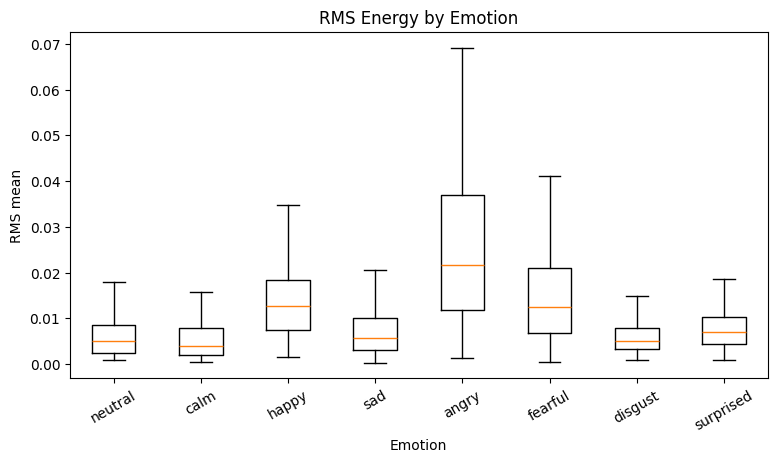

In [38]:
fig, ax = plt.subplots(figsize=(9, 4.5))
data = [features.loc[features["emotion"] == emo, "rms_mean"].values for emo in emotion_order]
ax.boxplot(data, labels=emotion_order, showfliers=False)
ax.set_title("RMS Energy by Emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("RMS mean")
ax.tick_params(axis="x", rotation=30)
plt.show()


RMS energy is related to loudness. The distributions overlap, but emotions such as angry often show higher energy than quieter classes. This overlap is one reason SER is hard to classify.


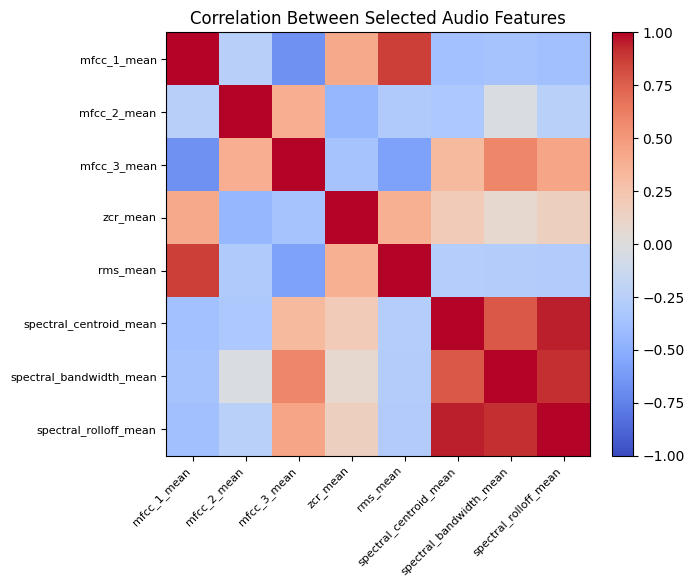

In [39]:
selected = ["mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "zcr_mean", "rms_mean", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean"]
corr = features[selected].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(selected)))
ax.set_yticks(range(len(selected)))
ax.set_xticklabels(selected, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(selected, fontsize=8)
ax.set_title("Correlation Between Selected Audio Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


The correlation plot shows that some spectral features are related to each other. This helps explain why Naive Bayes struggled since its independence assumption does not fit highly related audio features very well.


Standardization was applied after splitting the data. The scaler was fit on training data only, then reused on validation/test data. This prevents data leakage because the test set distribution is not used to set the scaling parameters.


## 4. Classical Supervised Models

This section is based mainly on Weeks 6 and 7. Week 6 does some exploratory regression, but the main SER task is classification, so the final comparison focuses on Logistic Regression, Gaussian Naive Bayes, and KNN.

The table below is calculated from `week5_audio.csv` using one fixed stratified split so the models use the same train/test rows.


In [40]:
prepare_model_data()

model_rows = []
model_rows.append(fit_and_score(LogisticRegression(learning_rate=0.1, n_iter=500), "Logistic Regression", "MiniLearn", "lr=0.1, n_iter=500", X_train_scaled, y_train, X_test_scaled, y_test))
model_rows.append(fit_and_score(SKLogisticRegression(max_iter=5000, random_state=RANDOM_STATE), "Logistic Regression", "sklearn", "max_iter=5000", X_train_scaled, y_train, X_test_scaled, y_test))
model_rows.append(fit_and_score(KNN(n_neighbors=5), "KNN", "MiniLearn", "k=5", X_train_scaled, y_train, X_test_scaled, y_test))
model_rows.append(fit_and_score(SKKNN(n_neighbors=5), "KNN", "sklearn", "k=5", X_train_scaled, y_train, X_test_scaled, y_test))
model_rows.append(fit_and_score(SKGaussianNB(), "Gaussian Naive Bayes", "sklearn", "default", X_train_scaled, y_train, X_test_scaled, y_test))
model_rows.append(fit_and_score(GaussianNaiveBayes(), "Gaussian Naive Bayes", "MiniLearn", "default", X_train_scaled, y_train, X_test_scaled, y_test))

model_summary = pd.DataFrame(model_rows).sort_values("weighted_F1", ascending=False).reset_index(drop=True)
classical = model_summary[model_summary["model"].isin(["Logistic Regression", "Gaussian Naive Bayes", "KNN"])]
classical[["model", "library", "parameters", "accuracy", "weighted_precision", "weighted_recall", "weighted_F1"]]


,model,library,parameters,accuracy,weighted_precision,weighted_recall,weighted_F1
0,Logistic Regression,MiniLearn,"lr=0.1, n_iter=500",0.7055,0.7042,0.7055,0.7022
1,Logistic Regression,sklearn,max_iter=5000,0.6524,0.6506,0.6524,0.6482
2,KNN,MiniLearn,k=5,0.5501,0.5489,0.5501,0.5422
3,KNN,sklearn,k=5,0.5501,0.5489,0.5501,0.5422
4,Gaussian Naive Bayes,sklearn,default,0.2883,0.3533,0.2883,0.2815
5,Gaussian Naive Bayes,MiniLearn,default,0.1534,0.0235,0.1534,0.0408


MiniLearn Logistic Regression was the strongest classical model in this fixed split comparison. KNN matched exactly between MiniLearn and sklearn. Gaussian Naive Bayes was the weakest, especially in MiniLearn, because zero-variance features and correlated audio features make its assumptions less reliable.


## 5. Support Vector Machines

This section is based on Week 8. MiniLearn included a simplified linear SVM. Scikit-learn was used to compare linear, RBF, and polynomial kernels.


In [41]:
np.random.seed(RANDOM_STATE + 1)
X_svm_train, X_svm_val, y_svm_train, y_svm_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train)
X_svm_train_scaled, X_svm_val_scaled = scale_train_test(X_svm_train, X_svm_val)

svm_configs = [
    ("linear svm", "sklearn", "C=0.1", SKSVC(kernel="linear", C=0.1, random_state=RANDOM_STATE)),
    ("linear svm", "sklearn", "C=1", SKSVC(kernel="linear", C=1, random_state=RANDOM_STATE)),
    ("linear svm", "sklearn", "C=10", SKSVC(kernel="linear", C=10, random_state=RANDOM_STATE)),
    ("rbf svm", "sklearn", "C=1, gamma=scale", SKSVC(kernel="rbf", C=1, gamma="scale", random_state=RANDOM_STATE)),
    ("rbf svm", "sklearn", "C=10, gamma=scale", SKSVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE)),
    ("rbf svm", "sklearn", "C=10, gamma=0.01", SKSVC(kernel="rbf", C=10, gamma=0.01, random_state=RANDOM_STATE)),
    ("poly svm", "sklearn", "C=1, degree=3", SKSVC(kernel="poly", C=1, degree=3, gamma="scale", random_state=RANDOM_STATE)),
    ("poly svm", "sklearn", "C=10, degree=3", SKSVC(kernel="poly", C=10, degree=3, gamma="scale", random_state=RANDOM_STATE)),
]

svm_validation = pd.DataFrame([
    fit_and_score(model, name, library, parameters, X_svm_train_scaled, y_svm_train, X_svm_val_scaled, y_svm_val)
    for name, library, parameters, model in svm_configs
]).sort_values("weighted_F1", ascending=False).reset_index(drop=True)
svm_validation


,model,library,parameters,accuracy,weighted_precision,weighted_recall,weighted_F1
0,rbf svm,sklearn,"C=10, gamma=scale",0.6667,0.6659,0.6667,0.6623
1,linear svm,sklearn,C=0.1,0.6074,0.6062,0.6074,0.6026
2,linear svm,sklearn,C=1,0.5992,0.5956,0.5992,0.5939
3,linear svm,sklearn,C=10,0.5992,0.5956,0.5992,0.5939
4,rbf svm,sklearn,"C=1, gamma=scale",0.5399,0.5469,0.5399,0.5308
5,rbf svm,sklearn,"C=10, gamma=0.01",0.5337,0.5525,0.5337,0.5276
6,poly svm,sklearn,"C=10, degree=3",0.3845,0.4858,0.3845,0.3543
7,poly svm,sklearn,"C=1, degree=3",0.2147,0.4009,0.2147,0.1519


The validation table shows that the RBF SVM with C=10, gamma=scale performed best among the tested SVM settings. This suggests that nonlinear decision boundaries helped with the audio emotion features.


In [42]:
svm_rows = []
svm_rows.append(fit_and_score(LinearSVM(learning_rate=0.001, n_iter=200, C=1.0), "Linear SVM", "MiniLearn", "C=1.0, n_iter=200", X_train_scaled, y_train, X_test_scaled, y_test))
svm_rows.append(fit_and_score(SKSVC(kernel="linear", C=1, random_state=RANDOM_STATE), "Linear SVM", "sklearn", "kernel=linear, C=1", X_train_scaled, y_train, X_test_scaled, y_test))
svm_rows.append(fit_and_score(SKSVC(kernel="rbf", C=10, gamma="scale", random_state=RANDOM_STATE), "RBF SVM", "sklearn", "C=10, gamma=scale", X_train_scaled, y_train, X_test_scaled, y_test))
svm_rows.append(fit_and_score(SKSVC(kernel="rbf", C=10, gamma=0.01, random_state=RANDOM_STATE), "RBF SVM", "sklearn", "C=10, gamma=0.01", X_train_scaled, y_train, X_test_scaled, y_test))
svm_rows.append(fit_and_score(SKSVC(kernel="poly", C=10, degree=3, gamma="scale", random_state=RANDOM_STATE), "Polynomial SVM", "sklearn", "C=10, degree=3, gamma=scale", X_train_scaled, y_train, X_test_scaled, y_test))

svm_final = pd.DataFrame(svm_rows).sort_values("weighted_F1", ascending=False).reset_index(drop=True)
model_summary = pd.concat([model_summary, svm_final], ignore_index=True)
svm_final[["model", "library", "parameters", "accuracy", "weighted_precision", "weighted_recall", "weighted_F1"]]


,model,library,parameters,accuracy,weighted_precision,weighted_recall,weighted_F1
0,RBF SVM,sklearn,"C=10, gamma=scale",0.7423,0.7509,0.7423,0.7385
1,RBF SVM,sklearn,"C=10, gamma=0.01",0.6299,0.6829,0.6299,0.6292
2,Linear SVM,sklearn,"kernel=linear, C=1",0.6339,0.6371,0.6339,0.6282
3,Linear SVM,MiniLearn,"C=1.0, n_iter=200",0.4908,0.5031,0.4908,0.4620
4,Polynomial SVM,sklearn,"C=10, degree=3, gamma=scale",0.4356,0.5422,0.4356,0.4051


The final SVM table confirms that the sklearn RBF SVM was the strongest overall model. MiniLearn LinearSVM was lower because it is simplified and only learns linear boundaries.


## 6. Decision Trees and Ensembles

This section is based on Week 9. Here miniLearn implemented a CART style decision tree. Scikit-learn models included a decision tree, random forest, and AdaBoost.


In [43]:
tree_rows = []
tree_rows.append(fit_and_score(DecisionTreeClassifier(max_depth=4, min_samples_split=5, max_thresholds=10), "CART Decision Tree", "MiniLearn", "max_depth=4, min_samples_split=5", X_train, y_train, X_test, y_test))
tree_rows.append(fit_and_score(SKDecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE), "Decision Tree", "sklearn", "max_depth=4", X_train, y_train, X_test, y_test))
tree_rows.append(fit_and_score(RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE), "Random Forest", "sklearn", "n_estimators=100, max_depth=8", X_train, y_train, X_test, y_test))
tree_rows.append(fit_and_score(AdaBoostClassifier(estimator=SKDecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), n_estimators=50, learning_rate=0.5, random_state=RANDOM_STATE), "AdaBoost", "sklearn", "tree stump, n_estimators=50, lr=0.5", X_train, y_train, X_test, y_test))

tree_models = pd.DataFrame(tree_rows).sort_values("weighted_F1", ascending=False).reset_index(drop=True)
model_summary = pd.concat([model_summary, tree_models], ignore_index=True)
tree_models[["model", "library", "parameters", "accuracy", "weighted_precision", "weighted_recall", "weighted_F1"]]


,model,library,parameters,accuracy,weighted_precision,weighted_recall,weighted_F1
0,Random Forest,sklearn,"n_estimators=100, max_depth=8",0.5624,0.5710,0.5624,0.5480
1,CART Decision Tree,MiniLearn,"max_depth=4, min_samples_split=5",0.4029,0.4160,0.4029,0.3705
2,Decision Tree,sklearn,max_depth=4,0.3845,0.3659,0.3845,0.3571
3,AdaBoost,sklearn,"tree stump, n_estimators=50, lr=0.5",0.3681,0.3131,0.3681,0.3273


Random Forest was the best tree based model. A single shallow tree was weaker because it cannot represent enough of the structure in a 724-feature audio table. AdaBoost also underperformed in this run, but likely because the simple tree stumps did not capture the emotion patterns well.


## 7. Model Evaluation and Validation

Validation is important because one train/test split can give a noisy view of performance. Cross-validation gives a better estimate by evaluating models across several folds. The table below is calculated from `week5_audio.csv` using stratified folds.


In [44]:
cv_models = [
    ("sklearn Logistic Regression", "max_iter=5000", lambda: SKLogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ("sklearn Random Forest", "n_estimators=100, max_depth=8", lambda: RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE)),
    ("MiniLearn KNN", "k=5", lambda: KNN(n_neighbors=5)),
    ("sklearn KNN", "k=5", lambda: SKKNN(n_neighbors=5)),
]
folds = kfold_split(y_all, n_splits=3, shuffle=False)
cv_rows = []

for model_name, parameters, make_model in cv_models:
    scores = []
    for train_idx, valid_idx in folds:
        X_fold_train, X_fold_valid = scale_train_test(X_all[train_idx], X_all[valid_idx])
        y_fold_train = y_all[train_idx]
        y_fold_valid = y_all[valid_idx]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = make_model()
            model.fit(X_fold_train, y_fold_train)
            preds = model.predict(X_fold_valid)
        scores.append(float(accuracy_score(y_fold_valid, preds)))
    cv_rows.append({
        "model": model_name,
        "parameters": parameters,
        "mean_cv_accuracy": round(float(np.mean(scores)), 4),
        "std_cv_accuracy": round(float(np.std(scores)), 4),
        "fold_scores": [round(s, 4) for s in scores],
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_cv_accuracy", ascending=False).reset_index(drop=True)
cv_results


,model,parameters,mean_cv_accuracy,std_cv_accuracy,fold_scores
0,sklearn Logistic Regression,max_iter=5000,0.6403,0.0094,"[0.6516, 0.6287, 0.6405]"
1,MiniLearn KNN,k=5,0.5942,0.0176,"[0.6054, 0.6078, 0.5693]"
2,sklearn KNN,k=5,0.5942,0.0176,"[0.6054, 0.6078, 0.5693]"
3,sklearn Random Forest,"n_estimators=100, max_depth=8",0.5897,0.0094,"[0.6029, 0.5833, 0.5828]"


Logistic Regression had the highest mean cross-validation accuracy among the models tested in this validation summary. KNN was lower and matched between MiniLearn and sklearn.


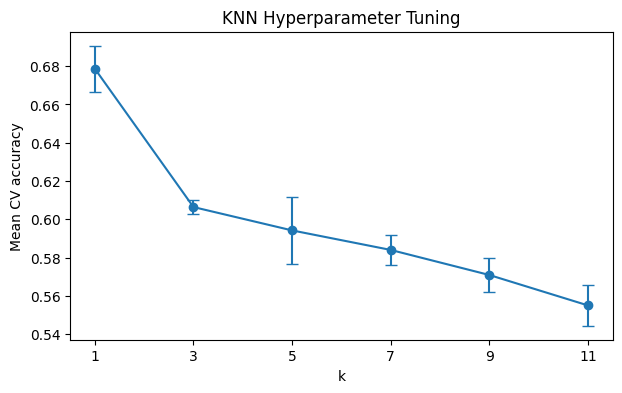

,k,mean_cv_accuracy,std_cv_accuracy
0,1,0.6787,0.0120
1,3,0.6064,0.0036
2,5,0.5942,0.0176
3,7,0.5840,0.0078
4,9,0.5709,0.0089
5,11,0.5550,0.0106


In [45]:
k_values = [1, 3, 5, 7, 9, 11]
knn_rows = []

for k in k_values:
    scores = []
    for train_idx, valid_idx in folds:
        X_fold_train, X_fold_valid = scale_train_test(X_all[train_idx], X_all[valid_idx])
        y_fold_train = y_all[train_idx]
        y_fold_valid = y_all[valid_idx]
        model = SKKNN(n_neighbors=k)
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_valid)
        scores.append(float(accuracy_score(y_fold_valid, preds)))
    knn_rows.append({
        "k": k,
        "mean_cv_accuracy": round(float(np.mean(scores)), 4),
        "std_cv_accuracy": round(float(np.std(scores)), 4),
    })

knn_tuning = pd.DataFrame(knn_rows)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(knn_tuning["k"], knn_tuning["mean_cv_accuracy"], yerr=knn_tuning["std_cv_accuracy"], marker="o", capsize=4)
ax.set_title("KNN Hyperparameter Tuning")
ax.set_xlabel("k")
ax.set_ylabel("Mean CV accuracy")
ax.set_xticks(knn_tuning["k"])
plt.show()

knn_tuning


The KNN tuning plot shows that k=1 had the highest mean CV accuracy among the tested values. However, k=1 can overfit because each prediction depends on only one neighbor.


The final values are calculated using one fixed split so that the model comparison is consistent. Some notebook outputs used different random splits, so the exact values in notebooks may not match the final fixed split tables.

## 8. Clustering

This section is based on Week 11. KMeans was applied with k=8 because there are eight emotion labels. I also calculated agglomerative clustering.


In [46]:
np.random.seed(RANDOM_STATE)
minilearn_kmeans = KMeans(n_clusters=8, max_iter=100).fit(X_all_scaled)
sklearn_kmeans = SKKMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10).fit(X_all_scaled)
agglomerative = AgglomerativeClustering(n_clusters=8).fit(X_all_scaled)

clustering = pd.DataFrame([
    {"model": "MiniLearn KMeans", "k": 8, "ARI": round(float(adjusted_rand_score(y_all, minilearn_kmeans.labels_)), 4), "NMI": round(float(normalized_mutual_info_score(y_all, minilearn_kmeans.labels_)), 4)},
    {"model": "sklearn KMeans", "k": 8, "ARI": round(float(adjusted_rand_score(y_all, sklearn_kmeans.labels_)), 4), "NMI": round(float(normalized_mutual_info_score(y_all, sklearn_kmeans.labels_)), 4)},
    {"model": "sklearn Agglomerative", "k": 8, "ARI": round(float(adjusted_rand_score(y_all, agglomerative.labels_)), 4), "NMI": round(float(normalized_mutual_info_score(y_all, agglomerative.labels_)), 4)},
])
clustering


,model,k,ARI,NMI
0,MiniLearn KMeans,8,0.0361,0.1030
1,sklearn KMeans,8,0.0082,0.0688
2,sklearn Agglomerative,8,0.0058,0.0623


ARI and NMI are both low, so the clusters did not match the true emotion labels very well. This doesn't mean the supervised models failed but it means the emotion classes are not naturally separated into simple unsupervised distance groups.

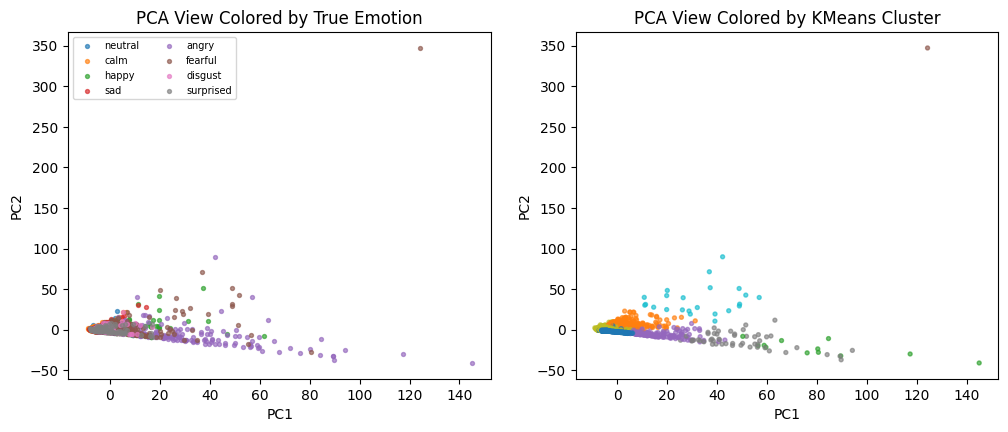

In [47]:
from sklearn.preprocessing import StandardScaler as SKStandardScaler
from sklearn.decomposition import PCA as SKPCA
from sklearn.cluster import KMeans as SKKMeans

X_sample = features[feature_cols].to_numpy(dtype=float)
y_labels = features["emotion"].to_numpy()
X_scale = SKStandardScaler().fit_transform(X_sample)
X_2d = SKPCA(n_components=2, random_state=123).fit_transform(X_scale)
cluster_labels = SKKMeans(n_clusters=8, random_state=123, n_init=10).fit_predict(X_scale)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for emo in emotion_order:
    mask = y_labels == emo
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], s=8, alpha=0.65, label=emo)
axes[0].set_title("PCA View Colored by True Emotion")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7, ncol=2)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels, s=8, alpha=0.65, cmap="tab10")
axes[1].set_title("PCA View Colored by KMeans Cluster")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.show()


The PCA visualization shows a lot of overlap between true emotions. The KMeans cluster plot also does not visually separate clean emotion regions which matches the low ARI/NMI scores.


## 9. Dimensionality Reduction

This section is based on Week 12. MiniLearn PCA was used to reduce the 724 dimensional feature matrix. PCA is useful for visualization and feature compression, but it does not always improve classification.


In [48]:
pca = PCA(n_components=20)
pca.fit(X_all_scaled)
pca_variance = pd.DataFrame({
    "component": np.arange(1, 21),
    "explained_variance_ratio": pca.explained_variance_r_,
})
pca_variance["cumulative_variance"] = pca_variance["explained_variance_ratio"].cumsum()
pca_variance = pca_variance.round(4)
pca_variance[pca_variance["component"].isin([1, 2, 5, 10, 20])]


,component,explained_variance_ratio,cumulative_variance
0,1,0.2136,0.2136
1,2,0.1179,0.3316
4,5,0.0354,0.4538
9,10,0.0152,0.5531
19,20,0.0081,0.6600


The first 20 principal components explain about 66% of the variance. That means a lot of information is spread across many dimensions, not only the first few components.


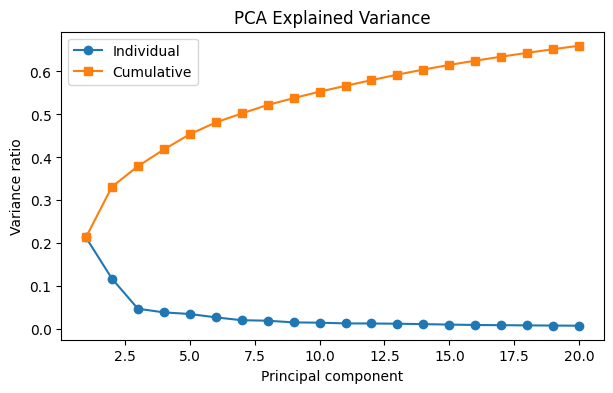

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pca_variance["component"], pca_variance["explained_variance_ratio"], marker="o", label="Individual")
ax.plot(pca_variance["component"], pca_variance["cumulative_variance"], marker="s", label="Cumulative")
ax.set_title("PCA Explained Variance")
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance ratio")
ax.legend()
plt.show()


The cumulative variance curve rises gradually. This supports the idea that reducing the feature set too aggressively might remove useful emotion information.


In [50]:
pca_model_rows = []
pca_model_rows.append(fit_and_score(SKLogisticRegression(max_iter=5000, random_state=RANDOM_STATE), "Logistic Regression - original features", "sklearn", "max_iter=5000", X_train_scaled, y_train, X_test_scaled, y_test))
pca_model_rows.append(fit_and_score(SKKNN(n_neighbors=5), "KNN - original features", "sklearn", "k=5", X_train_scaled, y_train, X_test_scaled, y_test))

for n_components in [2, 5, 10, 20]:
    pca_model = PCA(n_components=n_components)
    X_train_pca = pca_model.fit_transform(X_train_scaled)
    X_test_pca = pca_model.transform(X_test_scaled)
    pca_model_rows.append(fit_and_score(SKLogisticRegression(max_iter=5000, random_state=RANDOM_STATE), f"Logistic Regression - {n_components} PCs", "sklearn", f"n_components={n_components}", X_train_pca, y_train, X_test_pca, y_test))
    pca_model_rows.append(fit_and_score(SKKNN(n_neighbors=5), f"KNN - {n_components} PCs", "sklearn", f"n_components={n_components}, k=5", X_train_pca, y_train, X_test_pca, y_test))

pca_models = pd.DataFrame(pca_model_rows).sort_values("weighted_F1", ascending=False).reset_index(drop=True)
pca_models[["model", "accuracy", "weighted_precision", "weighted_recall", "weighted_F1"]]


,model,accuracy,weighted_precision,weighted_recall,weighted_F1
0,Logistic Regression - original features,0.6524,0.6506,0.6524,0.6482
1,KNN - original features,0.5501,0.5489,0.5501,0.5422
2,KNN - 20 PCs,0.4438,0.4379,0.4438,0.4319
3,Logistic Regression - 20 PCs,0.4090,0.4026,0.4090,0.3980
4,KNN - 10 PCs,0.3967,0.3888,0.3967,0.3878
5,Logistic Regression - 10 PCs,0.3824,0.3695,0.3824,0.3624
6,KNN - 5 PCs,0.3252,0.3096,0.3252,0.3108
7,Logistic Regression - 5 PCs,0.3129,0.2816,0.3129,0.2821
8,Logistic Regression - 2 PCs,0.2965,0.2500,0.2965,0.2552
9,KNN - 2 PCs,0.2597,0.2253,0.2597,0.2359


PCA hurt model performance in this project. Logistic Regression and KNN both performed better with the original 724 features than with 2, 5, 10, or 20 components.


## 10. ANN

This section is based on Week 13. This includes a MiniLearn simple ANN and an off-the-shelf sklearn Dense NN. The MiniLearn ANN has one hidden layer and uses ReLU plus softmax. The sklearn Dense NN uses two hidden layers.


In [51]:
ann_rows = []
ann_rows.append(fit_and_score(SimpleANNClassifier(hidden_size=24, learning_rate=0.03, n_iter=300, random_state=RANDOM_STATE), "Simple ANN", "MiniLearn", "hidden_size=24, lr=0.03, n_iter=300", X_train_scaled, y_train, X_test_scaled, y_test))
ann_rows.append(fit_and_score(MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE), "Dense NN", "sklearn", "hidden=(64,32), adam, max_iter=500", X_train_scaled, y_train, X_test_scaled, y_test))

logistic_rows = model_summary[model_summary["model"].eq("Logistic Regression")].copy()
ann_models = pd.concat([pd.DataFrame(ann_rows), logistic_rows], ignore_index=True).sort_values("weighted_F1", ascending=False).reset_index(drop=True)
model_summary = pd.concat([model_summary, pd.DataFrame(ann_rows)], ignore_index=True)
ann_models[["model", "library", "parameters", "accuracy", "weighted_precision", "weighted_recall", "weighted_F1"]]


,model,library,parameters,accuracy,weighted_precision,weighted_recall,weighted_F1
0,Dense NN,sklearn,"hidden=(64,32), adam, max_iter=500",0.7362,0.7356,0.7362,0.7333
1,Logistic Regression,MiniLearn,"lr=0.1, n_iter=500",0.7055,0.7042,0.7055,0.7022
2,Logistic Regression,sklearn,max_iter=5000,0.6524,0.6506,0.6524,0.6482
3,Simple ANN,MiniLearn,"hidden_size=24, lr=0.03, n_iter=300",0.6094,0.6099,0.6094,0.6053


The sklearn Dense NN was one of the strongest models, only slightly behind the best RBF SVM. The MiniLearn ANN was lower but still performed much better than chance for an eight class task.


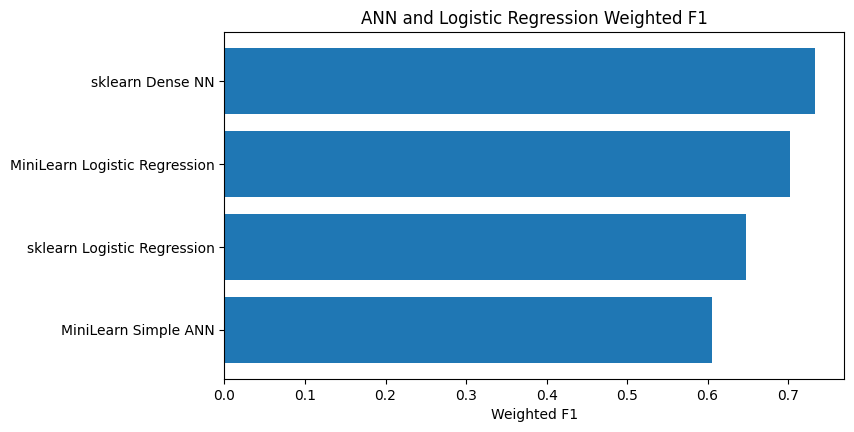

In [52]:
if "ann_models" in globals() and ann_models is not None and not ann_models.empty:
    plot_df = ann_models.copy()
    plot_df["label"] = plot_df["library"] + " " + plot_df["model"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(plot_df["label"], plot_df["weighted_F1"])
    ax.set_title("ANN and Logistic Regression Weighted F1")
    ax.set_xlabel("Weighted F1")
    ax.invert_yaxis()
    plt.show()


The Dense NN and MiniLearn Logistic Regression were both strong. This suggests the extracted features are informative, and nonlinear models can add more performance.


## 11. Overall

The best-performing model in the fixed-split calculation was the sklearn RBF SVM with C=10, gamma=scale. The sklearn Dense NN was also one of the strongest models in the final comparison.

The strongest MiniLearn model was Logistic Regression. This was a good result for a simple implementation. My miniLearn KNN matches sklearn KNN, which makes sense because both used the same nearest neighbor with k=5.

The weakest models were Gaussian Naive Bayes models, especially with my MiniLearn version. The audio features are correlated and high dimensional, which makes the Naive Bayes independence assumption weak. The MiniLearn version also has no smoothing, so zero-variance cases are difficult for it.

SER is difficult because emotions overlap. Angry and fearful can both have high energy. Calm and sad can sound similar. Speakers also differ by actor, gender, vocal style, and vocal channel. These differences make the problem harder than a simple clean classification problem.

Scaling was also important because many models depended on distances, gradients, margins, or variance. KNN, Logistic Regression, SVM, PCA, and ANN all needed standardized features. Trees are less sensitive to scaling because they split using thresholds.



## 12. Conclusion

My project built a complete SER pipeline from RAVDESS metadata parsing through feature extraction, MiniLearn models, sklearn comparisons, validation, clustering, PCA, and ANN experiments.

The best model was an sklearn RBF SVM. The Dense NN was very close, and MiniLearn Logistic Regression was the strongest one I made from scratch. PCA was useful for visualization but reduced classification performance when using a compressed feature representation. KMeans and clustering did not align well with emotion labels, which shows that supervised learning was more effective for doing this.

The biggest lessons I learned was that feature creating and scaling matter, model assumptions matter, and from scratch implementations are valuable for understanding even when libraries perform better.


## 13. References

Project and dataset references:

- Livingstone SR, Russo FA (2018). *The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS).* This citation appears in the project README.

Python libraries used:

- NumPy
- pandas
- matplotlib
- librosa
- scikit-learn
- MiniLearn project package


## Thank you!